#**<center>$\color{green}{\text{TUGAS 2 : KLASIFIKASI}}$</center>**

> Add blockquote



---


<p>
Universitas Terbuka adalah sebuah perguruan tinggi terbuka yang memberikan kesempatan bagi putra putri bangsa untuk menimba ilmu dan pengetahuan. UT memiliki mahasiswa dengan latar belakang yang beragam. Mahasiswanya tidak terbatas pada lulusan baru dari sma/smu/smk sederajat. Beberapa diantaranya bahkan telah/sedang bekerja. Kondisi tersebut memberikan kesulitan bagi pihak kampus dalam menerapkan strategi untuk membantu mahasiswa berhasil melewati masa kuliah dan lulus tepat waktu.
</p>

<p>
Sebagai seorang Machine Learning engineer, kamu diminta untuk membuat model yang mampu mendeteksi secara dini tigkat resiko kegagalan seorang mahasiswa. Dengan harapan jika sistem mampu memberikan informasi yang valid, maka bagian wali akademik dapat memberikan konseling yang tepat. Untuk melaksanakan tugasmu ini, kamu diberikan data yang bersumber dari dua periode penerimaan.
</p>


##Task 1
Mulailah memuat semua data yang ada ke sistem.

In [170]:
import pandas as pd
import numpy as np
 
# 1) Muat data dari kedua sumber
# ...
[df1,df2] = pd.read_csv("./Data Siswa Periode 1.csv") ,pd.read_csv("./Data Siswa Periode 2.csv")
df1.head()
df2.head()
# 2) Lihat atribut apa saja yang ada dari kedua data tersebut
# ...
print(f"{df1.info()}\n{df1.describe()} \n {df2.info()}\n{df1.describe()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   1827 non-null   int64  
 1   Status Pernikahan                    1827 non-null   object 
 2   Program Studi                        1827 non-null   object 
 3   Kelas Reguler/Malam                  1824 non-null   object 
 4   Pendidikan Terakhir                  1827 non-null   object 
 5   Nilai SMA                            1827 non-null   float64
 6   Daerah Asal                          1824 non-null   object 
 7   Pendidikan Ibu                       1827 non-null   object 
 8   Pendidikan Ayah                      1827 non-null   object 
 9   Pekerjaan Ibu                        1827 non-null   object 
 10  Pekerjaan Ayah                       1827 non-null   object 
 11  Nilai Ujian Masuk             

##Task 2
Datanya sudah termuat, fitur nya hampir semuanya sama, tetapi ada yang berbeda sehingga perlu dipetakan

In [171]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa
# ...
df1.columns = df1.columns.str.strip().str.lower().str.replace(' ','_')
df2.columns = df1.columns
df1.set_index("id")
df2.set_index("id")
#print(f"{df1.columns}\n{df2.columns}")
print(f"{df1.info()}\n{df2.info()}")
df1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1827 non-null   int64  
 1   status_pernikahan                    1827 non-null   object 
 2   program_studi                        1827 non-null   object 
 3   kelas_reguler/malam                  1824 non-null   object 
 4   pendidikan_terakhir                  1827 non-null   object 
 5   nilai_sma                            1827 non-null   float64
 6   daerah_asal                          1824 non-null   object 
 7   pendidikan_ibu                       1827 non-null   object 
 8   pendidikan_ayah                      1827 non-null   object 
 9   pekerjaan_ibu                        1827 non-null   object 
 10  pekerjaan_ayah                       1827 non-null   object 
 11  nilai_ujian_masuk             

,id,status_pernikahan,program_studi,kelas_reguler/malam,pendidikan_terakhir,nilai_sma,daerah_asal,pendidikan_ibu,pendidikan_ayah,pekerjaan_ibu,...,nilai_ujian_masuk,pindahan,berkebutuhan_khusus,status_pembayaran_semester_terakhir,jenis_kelamin,beasiswa,usia_saat_mendaftar,ip_semester_1,ip_semester_2,target
0,2,Belum Menikah,Teknik Industri,Reguler,SMA/Sederajat,66.55,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,53.00,Ya,Tidak,Sudah,Pria,Tidak,21,2.48,2.52,Lulus Tepat Waktu
1,3,Belum Menikah,Jurnalistik,Reguler,SMA/Sederajat,63.50,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,58.25,Tidak,Tidak,Sudah,Wanita,Ya,19,2.86,2.63,Lulus Tepat Waktu
2,4,Belum Menikah,Pertanian,Reguler,SMA/Sederajat,62.50,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Wiraswasta,...,60.75,Ya,Tidak,Sudah,Pria,Tidak,18,2.20,2.07,Lulus Tidak Tepat Waktu
3,5,Belum Menikah,Teknik Mesin,Reguler,Perguruan Tinggi,75.00,Pulau Jawa,Lebih dari S1,Lebih dari S1,Pegawai Swasta,...,75.00,Tidak,Tidak,Sudah,Wanita,Tidak,20,2.60,2.40,Lulus Tidak Tepat Waktu
4,10,Belum Menikah,Perbankan,Reguler,SMA/Sederajat,65.00,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Pegawai Negri,...,64.55,Ya,Tidak,Sudah,Wanita,Tidak,18,2.61,2.72,Lulus Tepat Waktu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,32,Belum Menikah,Perpajakan,Reguler,SMA/Sederajat,66.00,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,66.55,Ya,Tidak,Sudah,Pria,Tidak,19,2.40,2.10,Gagal
1823,34,Cerai,Jurnalistik,Reguler,Perguruan Tinggi,66.55,Pulau Jawa,Lebih dari S1,Lebih dari S1,Pegawai Swasta,...,58.75,Tidak,Tidak,Sudah,Wanita,Tidak,39,2.25,2.27,Lulus Tepat Waktu
1824,35,Belum Menikah,Perpajakan,Reguler,Perguruan Tinggi,75.00,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,75.00,Ya,Tidak,Sudah,Pria,Tidak,20,3.30,3.54,Gagal
1825,36,Belum Menikah,Perbankan,Reguler,SMA/Sederajat,65.00,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,58.90,Ya,Tidak,Sudah,Wanita,Ya,19,2.47,2.47,Lulus Tepat Waktu


##Task 3
Butuh penyatuan data, tapi ternyata ada kodefikasi atribut fitur yang berbeda, harus di samakan

In [224]:
from sklearn.preprocessing import OrdinalEncoder
# print(f"{df1}\n{df2}")
# 1) Lakukan penyamaan kodefikasi atribut
# ...
def encode (d : pd.DataFrame,dto : list,enc : dict):
    for c in dtObject:
            le = OrdinalEncoder(encoded_missing_value=np.nan)
            encode_array = le.fit_transform(d[[c]]).flatten()
            d[c] = pd.Series(encode_array,index=d.index).astype("Int64")
            categories = le.categories_[0]
            enc[c] = {label: idx for idx, label in enumerate(categories)}
dtObject = []
dtNum = []
Encoder = {}
for d in df1.columns:
    if df1[d].dtype in ["object"]:
        dtObject.append(d) 
    if df1[d].dtype in ["int64","float64"]: 
        dtNum.append(d)


# 2) Lakukan penyatuan data
# ...
print(f"data object : {dtObject}\ndata num :{dtNum}")
    
dfg = pd.concat([df1,df2],join="inner",ignore_index=True).sort_values(by='id')
dfg.set_index('id')
encode(dfg,dtObject,Encoder)
for key,val in Encoder.items():
    print(f"{key}, {val}") 
dfg



data object : ['status_pernikahan', 'program_studi', 'kelas_reguler/malam', 'pendidikan_terakhir', 'daerah_asal', 'pendidikan_ibu', 'pendidikan_ayah', 'pekerjaan_ibu', 'pekerjaan_ayah', 'pindahan', 'berkebutuhan_khusus', 'status_pembayaran_semester_terakhir', 'jenis_kelamin', 'beasiswa', 'target']
data num :['id', 'nilai_sma', 'nilai_ujian_masuk', 'usia_saat_mendaftar', 'ip_semester_1', 'ip_semester_2']
status_pernikahan, {'Belum Menikah': 0, 'Cerai': 1, 'Menikah': 2}
program_studi, {'Agronomi': 0, 'Akuntansi': 1, 'Ekonomi': 2, 'Hubungan Masyarakat': 3, 'Jurnalistik': 4, 'Keperawatan': 5, 'Manajemen': 6, 'Pariwisata': 7, 'Penyiaran': 8, 'Perbankan': 9, 'Perpajakan': 10, 'Perpustakaan': 11, 'Pertanian': 12, 'Teknik Industri': 13, 'Teknik Mesin': 14, 'Teknologi Informasi': 15}
kelas_reguler/malam, {'Malam': 0, 'Reguler': 1, 'Siang': 2, nan: 3}
pendidikan_terakhir, {'Perguruan Tinggi': 0, 'SMA/Sederajat': 1}
daerah_asal, {'Luar Jawa': 0, 'Pulau Jawa': 1, nan: 2}
pendidikan_ibu, {'D3/S1/Se

,id,status_pernikahan,program_studi,kelas_reguler/malam,pendidikan_terakhir,nilai_sma,daerah_asal,pendidikan_ibu,pendidikan_ayah,pekerjaan_ibu,...,nilai_ujian_masuk,pindahan,berkebutuhan_khusus,status_pembayaran_semester_terakhir,jenis_kelamin,beasiswa,usia_saat_mendaftar,ip_semester_1,ip_semester_2,target
914,1,0,0,1,1,70.00,1,2,2,2,...,70.00,1,0,1,3,0,36,2.61,2.60,1
0,2,0,13,1,1,66.55,1,1,3,0,...,53.00,1,0,1,2,0,21,2.48,2.52,1
1,3,0,4,1,1,63.50,1,3,2,2,...,58.25,0,0,1,3,1,19,2.86,2.63,1
2,4,0,12,1,1,62.50,1,1,3,3,...,60.75,1,0,1,2,0,18,2.20,2.07,2
3,5,0,14,1,0,75.00,1,2,2,2,...,75.00,0,0,1,3,0,20,2.60,2.40,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2653,3531,0,9,2,1,67.50,1,1,2,3,...,63.75,1,0,1,1,1,19,2.75,2.98,1
2654,3532,0,10,2,1,84.00,1,3,3,3,...,85.60,0,0,1,0,1,18,3.47,3.71,1
3551,3533,0,14,2,1,61.50,1,1,1,3,...,58.35,1,0,1,0,1,20,2.64,0.00,0
2655,3534,0,9,2,1,75.00,1,2,2,2,...,65.15,0,0,1,1,1,19,3.02,3.02,1


##Task 4
Sekarang kita lakukan analisis atribut untuk setiap fitur nya, mulai dengan penanganan missing/null value

In [225]:
# 1)	Identifikasi dan tangani missing/null value
# ...

print(f"data1 null \n{ dfg[dfg.isna().any(axis=1)]}")
dfg.fillna({"kelas_reguler/malam" : 1 if "target"==1 else 0,"daerah_asal" : 0},axis=0,inplace=True)
dfg

data1 null 
        id  status_pernikahan  program_studi  kelas_reguler/malam  \
1121   382                  0              4                    1   
1368   924                  0              8                    1   
658   1317                  0              0                 <NA>   
724   1424                  0              9                    1   
1624  1456                  0              6                 <NA>   
1764  1719                  0              1                 <NA>   

      pendidikan_terakhir  nilai_sma  daerah_asal  pendidikan_ibu  \
1121                    1       79.5         <NA>               1   
1368                    1       58.5         <NA>               1   
658                     1       54.0            1               3   
724                     1       75.0         <NA>               3   
1624                    1       65.0            0               2   
1764                    1       70.0            1               2   

      pendidikan_aya

,id,status_pernikahan,program_studi,kelas_reguler/malam,pendidikan_terakhir,nilai_sma,daerah_asal,pendidikan_ibu,pendidikan_ayah,pekerjaan_ibu,...,nilai_ujian_masuk,pindahan,berkebutuhan_khusus,status_pembayaran_semester_terakhir,jenis_kelamin,beasiswa,usia_saat_mendaftar,ip_semester_1,ip_semester_2,target
914,1,0,0,1,1,70.00,1,2,2,2,...,70.00,1,0,1,3,0,36,2.61,2.60,1
0,2,0,13,1,1,66.55,1,1,3,0,...,53.00,1,0,1,2,0,21,2.48,2.52,1
1,3,0,4,1,1,63.50,1,3,2,2,...,58.25,0,0,1,3,1,19,2.86,2.63,1
2,4,0,12,1,1,62.50,1,1,3,3,...,60.75,1,0,1,2,0,18,2.20,2.07,2
3,5,0,14,1,0,75.00,1,2,2,2,...,75.00,0,0,1,3,0,20,2.60,2.40,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2653,3531,0,9,2,1,67.50,1,1,2,3,...,63.75,1,0,1,1,1,19,2.75,2.98,1
2654,3532,0,10,2,1,84.00,1,3,3,3,...,85.60,0,0,1,0,1,18,3.47,3.71,1
3551,3533,0,14,2,1,61.50,1,1,1,3,...,58.35,1,0,1,0,1,20,2.64,0.00,0
2655,3534,0,9,2,1,75.00,1,2,2,2,...,65.15,0,0,1,1,1,19,3.02,3.02,1


##Task 5
Untuk bisa melihat bentuk dari data, kita perlu menghitung histogram dari setiap fitur. Dari situ kemudian kita bisa lanjutkan dengan penanganan outlier.

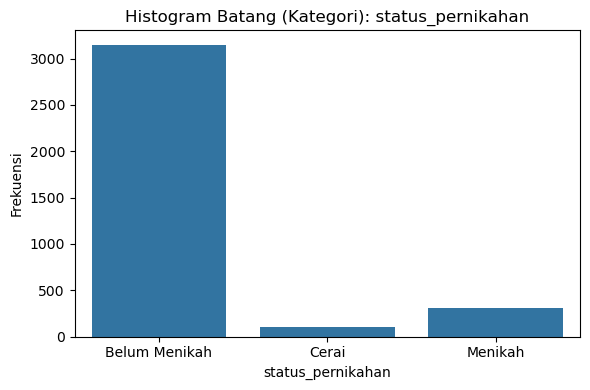

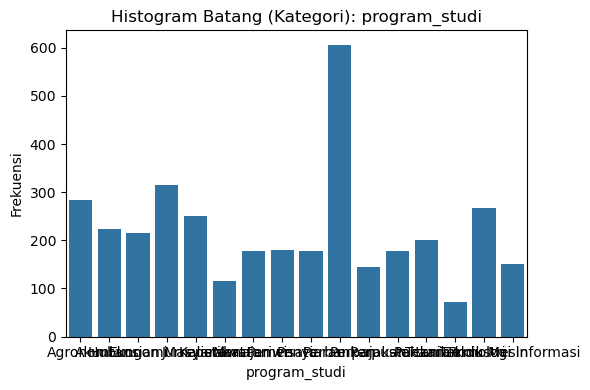

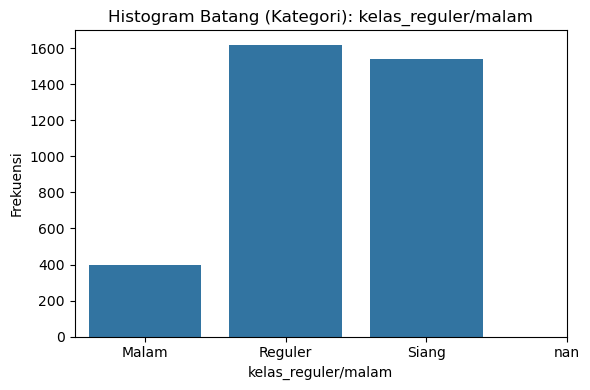

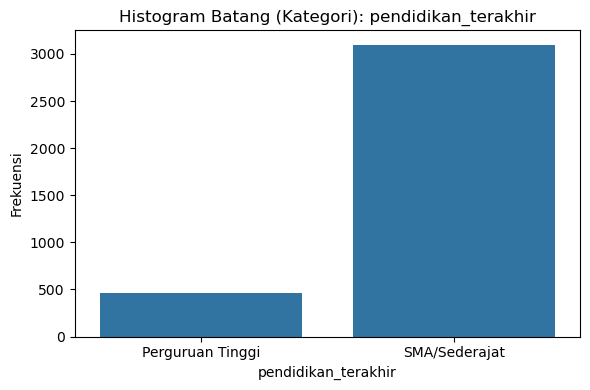

KeyError: 'nilai_sma'

<Figure size 600x400 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1)	Hitung histogram setiap fitur, tampilkan dalam bentuk grafik batang
# ...
for c in dfg.columns:
    if c == "id": 
        continue

    plt.figure(figsize=(6, 4))
    if c in dtObject:
        enc = list(Encoder[c].keys())
        # Untuk data kategori yang sudah di-encode, urutkan berdasarkan index mappingnya
        sns.countplot(data=dfg, x=c)
        plt.title(f"Histogram Batang (Kategori): {c}")
        plt.xticks(ticks=range(len(enc)),labels=enc)
    else:
        # Untuk data numerik murni
        sns.histplot(data=dfg, x=c, kde=True, color="skyblue")
        plt.title(f"Distribusi dan Histogram: {c}")
    
    plt.xlabel(c)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()
# 2)	Identifikasi outlier dengan boxplot
# ...

# 3)	Hapus outlier dari data
# ...


##Task 6
Agar nantinya kita bisa mendapatkan fitur yang relevan, sebaiknya kita melihat hubungan setiap fitur dengan kelas target.

In [5]:
# 1)	Lakukan analisis bivariate
# ...

# 2)	Plot kedalam grafik sebaran (scatter)
# ...


##Task 7
Oke, sepertinya sudah siap, tapi kok jumlah data per-kelas nya tidak seimbang ya, ada beberapa algoritma yang akan terpengaruh dengan kondisi ini, kita akan gunakan algoritma **$\color{orange}{\text{(Nama Algoritma)}}$** untuk menyelesaikan masalah ini, jadi kita **$\color{orange}{\text{(akan/tidak akan)}}$** melakukan proses augmentasi data karena **$\color{orange}{\text{(Alasan melakukan augmentasi/tidak)}}$**

In [6]:
# 1)	Augmentasi data untuk balancing kelas (Optional)
# ...

Selanjutnya datanya perlu kita bagi dengan ratio **$\color{orange}{\text{(.?.)}}$** : **$\color{orange}{\text{(.?.)}}$**
Dimana **$\color{orange}{\text{(.?.)}}$** adalah data training
Dan **$\color{orange}{\text{(.?.)}}$** adalah data testing


In [7]:
# 1)	Lakukan pembagian data training dan testing
# ...

##Task 8
Sekarang kita mulai training nya

In [8]:
# 1)	Lakukan proses training dengan algoritma yang telah dipilih
# ...

# 2)	Lakukan evaluasi model dengan K-fold
# ...


#Task 9
Training sudah selesai dan model sudah diketahui, kita uji hasilnya dengan data testing untuk melihat kemungkinan overfitting dan underfitting, sekaligus menghitung kualitas model dengan matrik pengukuran

In [9]:
# 1)	Evaluasi dengan data testing
# ...

# 2)	Hitung dengan matrik pengukuran
# ...

##Task 10
Berdasarkan hasil evaluasi, kita bisa menyimpulkan bahwa

**$\color{orange}{\text{(Lakukan analisis hasil )}}$**